# **EDA Handwritten Character Recognition**

The **EMNIST** ((https://www.kaggle.com/datasets/crawford/emnist)) Balanced dataset was used to solve the handwritten character recognition problem. It contains images of digits (0-9) and uppercase letters (A-Z). The data was sourced from two files:


*   **emnist-balanced-train.csv:** This file contains training data with images of digits (0-9) and uppercase letters (A-Z). Images of lowercase letters were excluded, as they are not necessary for this specific task.
*   **emnist-balanced-test.txt:** This file was used for testing the model. It contains 500 images of digits (0-9) and uppercase letters (A-Z).





**Data Format**

The dataset is provided in CSV format, where each row corresponds to a single image. The structure of the CSV file is as follows:

785 columns per row:


*   The first column contains the class label, which corresponds to the character being represented (e.g., 0 for digit '0', 1 for digit '1', etc.).
*   The remaining 784 columns represent pixel values for a 28x28 grayscale image, with each column corresponding to one pixel's intensity (ranging from 0 to 255).


**Label Mapping**

The **emnist-balanced-mapping.txt** file provides the mapping between class labels and their respective ASCII codes. This file contains two columns:


*   The first column is the label number, corresponding to a specific class.
*   The second column contains the ASCII code of the character represented by the label.






In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import pairwise_distances
import zipfile
import random
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

**1.Load the Dataset**

In [ ]:
# Extract the training dataset
with zipfile.ZipFile('/content/emnist-balanced-train.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
# Load the training dataset
train_dataset = pd.read_csv("/content/emnist-balanced-train.csv")
# Create column names and assign to the DataFrame
columns = ['label'] + list(range(784))
train_dataset.columns = columns

# Display the first few rows
print(train_dataset.head(10))

   label  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  780  \
0     15  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
1      4  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
2     26  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
3     32  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
4     20  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
5      1  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
6     15  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
7     13  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
8     24  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
9     12  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   

   781  782  783  
0    0    0    0  
1    0    0    0  
2    0    0    0  
3    0    0    0  
4    0    0    0  
5    0    0    0

In [36]:
# Load label dictionary
label_dictionary = {}
with open("/content/emnist-balanced-mapping.txt", "r") as file:
    for line in file:
        index, label = map(int, line.strip().split())
        label_dictionary[index] = chr(label)

print(label_dictionary)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


**2.Understand the Dataset: Understand the shape, size and nature of the images and labels.**

In [ ]:
#Display shape of the training dataset
print('Training Data Shape:', train_dataset.shape)
# Check for missing values and drop rows if any
print("Missing values in train dataset:", train_dataset.isna().any().any())
train_dataset = train_dataset.dropna()
print('Training Data Shape after dropping missing values:', train_dataset.shape)

# Separate class labels and pixel values
train_pixels = train_dataset.drop('label', axis=1)
train_labels = train_dataset['label'].astype('int').to_numpy()
train_pixels = np.reshape(train_pixels.values, (train_pixels.shape[0], 28, 28)) / 255

print("Train pixels shape:", train_pixels.shape)
num_classes=len(np.unique(train_labels))
print("Number of classes:",num_classes )

Training Data Shape: (86400, 785)
Missing values in train dataset: False
Training Data Shape after dropping missing values: (86400, 785)
Train pixels shape: (86400, 28, 28)
Number of classes: 36


**3.Visualize the Dataset**

In [ ]:
def display_sample_images(pixels, labels, label_dict):
    """
    Display a 5x5 grid of sample images from the dataset with their corresponding labels.

    Parameters
    ----------
    pixels : array-like
        Array of image data with shape (n_samples, height, width)
    labels : array-like
        Array of label indices corresponding to the images
    label_dict : dict
        Dictionary mapping label indices to their text descriptions

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    plt.figure(figsize=(10, 8))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(pixels[i], cmap='gray')
        plt.title(f'Label: {label_dict[labels[i]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

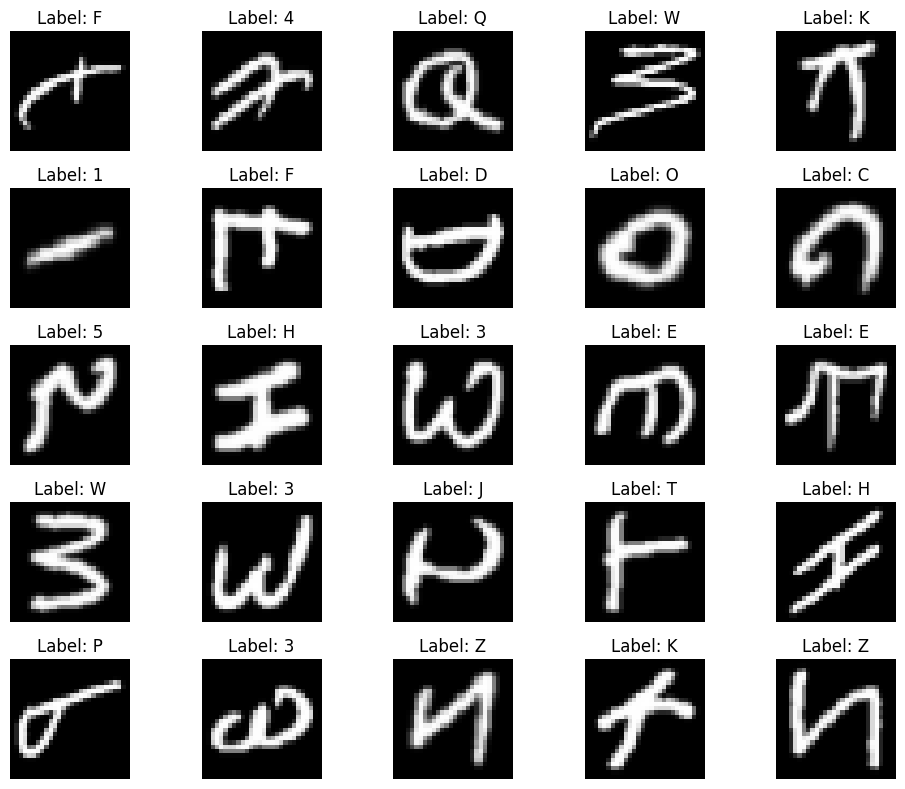

In [ ]:
display_sample_images(train_pixels, train_labels, label_dictionary)

We see that the images are rotated and flipped, so we need to horizontally flip and rotate these images by 90 degrees.

In [ ]:
# Function to rotate images
def rotate_image(image):
    """
    Rotate and flip an image by performing horizontal flip and 90-degree rotation.

    Parameters
    ----------
    image : numpy.ndarray
        Input image array with shape (channels, height, width)

    Returns
    -------
    numpy.ndarray
        Transformed image array with same shape as input

    Notes
    -----
    The transformation consists of:
    1. Horizontal flip along the width axis
    2. 90-degree rotation in the height-width plane
    """
    image = np.flip(image, axis=2)  # Flip horizontally
    image = np.rot90(image, axes=(1, 2))  # Rotate 90 degrees
    return image

In [ ]:
# Rotate the training and test images
train_pixels=rotate_image(train_pixels)

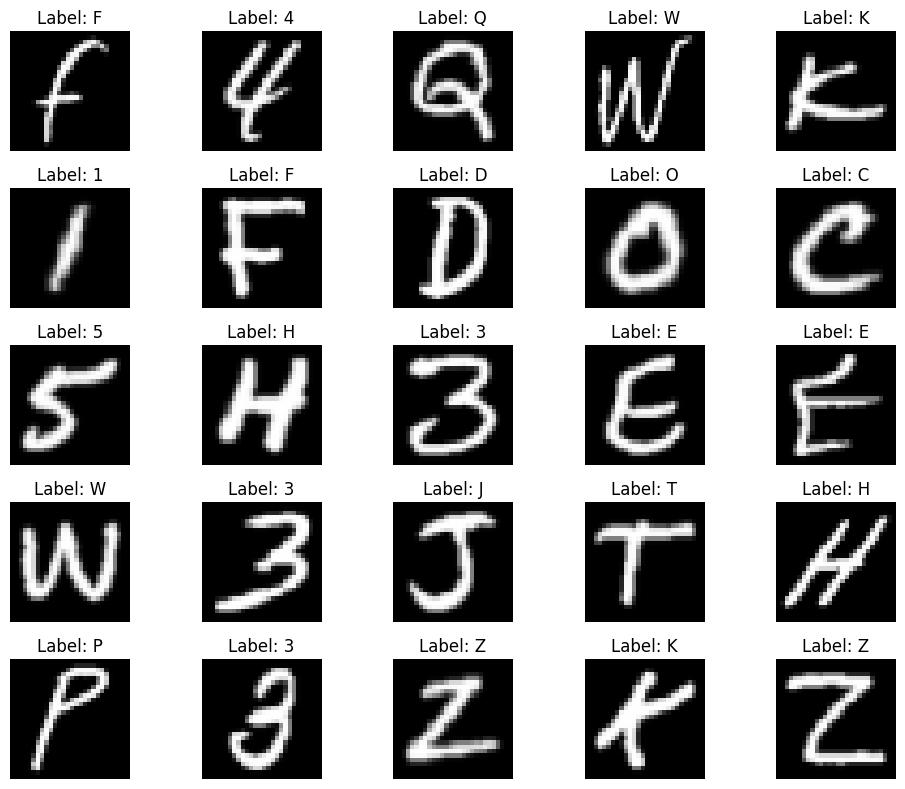

In [ ]:
# Display sample images from the training set after rotation
display_sample_images(train_pixels, train_labels, label_dictionary)

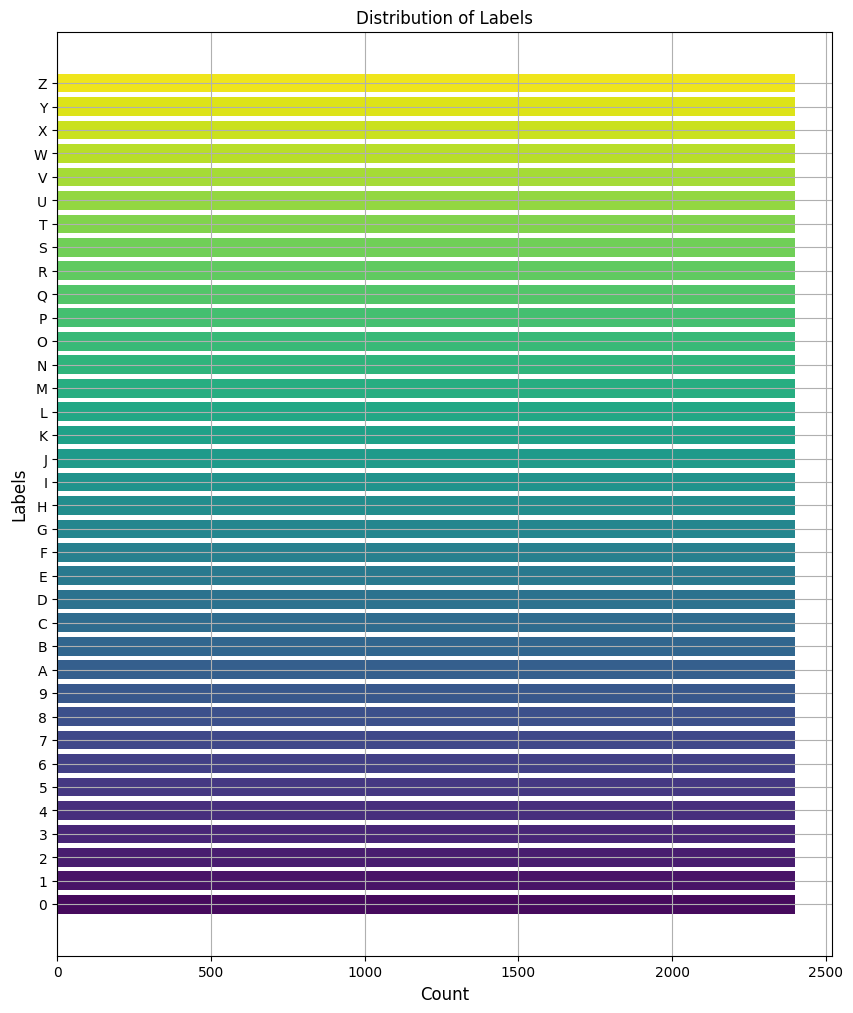

In [ ]:
# Visualize the distribution of labels
def visualize_label_distribution(labels, label_dict):
    """
    Create a horizontal bar chart showing the distribution of labels in the dataset.

    Parameters
    ----------
    labels : array-like
        Array of label indices representing the class of each sample
    label_dict : dict
        Dictionary mapping label indices to their text descriptions

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    # Calculate label frequencies
    unique_labels, label_counts = np.unique(labels, return_counts=True)

    # Create visualization
    plt.figure(figsize=(10, 12))
    plt.barh(unique_labels, label_counts, color=sns.color_palette('viridis', len(unique_labels)))
    plt.title('Distribution of Labels')
    plt.ylabel('Labels', fontsize=12)
    plt.xlabel('Count', fontsize=12)
    plt.grid(True)

    # Set custom labels
    names_labels = [label_dict[index] for index in unique_labels]
    plt.yticks(unique_labels, names_labels)
    plt.show()

visualize_label_distribution(train_labels, label_dictionary)

**4.Mean Images for Each Handwritten Character Class**

Let's create heatmaps for each class in the training set. For example, we can take all the samples of class "0", add them to the same image, and calculate the probabilities that each pixel will be colored in the case of class "0".

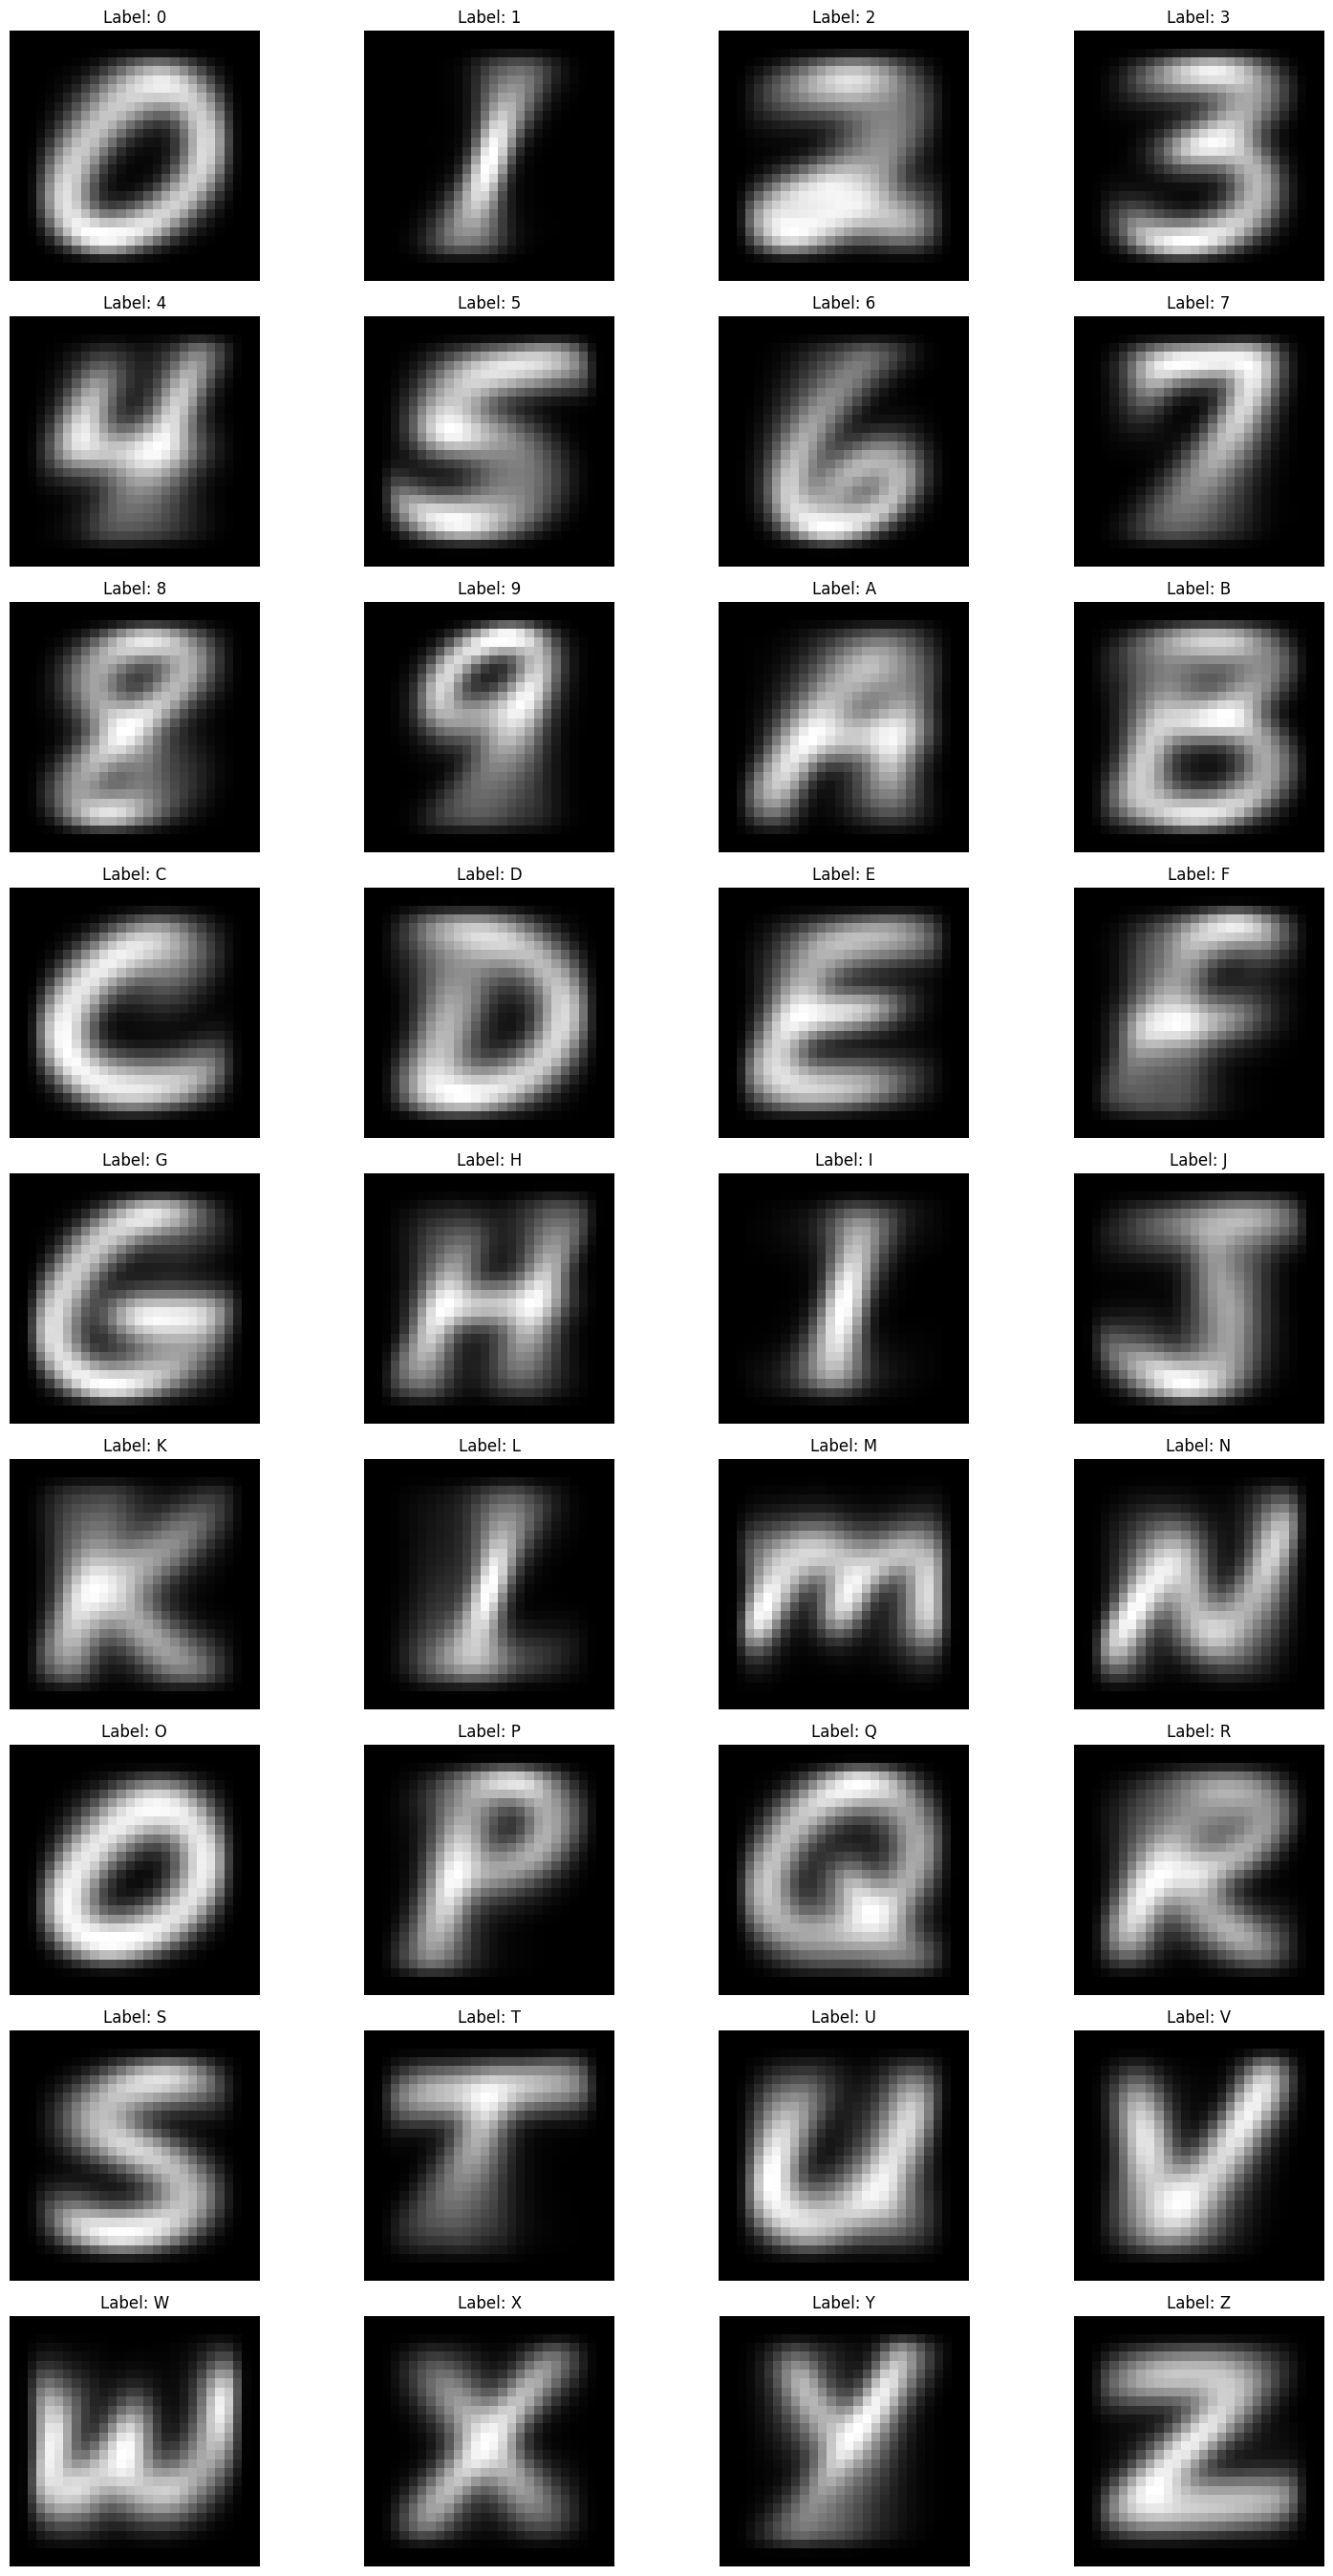

In [ ]:
def calculate_mean_images(images, labels, num_classes):
    """
    Calculate the mean image for each class in the dataset.

    Parameters
    ----------
    images : numpy.ndarray
        Array of image data with shape (n_samples, height, width)
    labels : numpy.ndarray
        Array of label indices with shape (n_samples,)
    num_classes : int
        Number of unique classes in the dataset

    Returns
    -------
    numpy.ndarray
        Array of mean images with shape (num_classes, height, width)
        Each element represents the average image for a class
    """
    mean_images = np.zeros((num_classes, 28, 28), dtype=np.float32)
    for label in range(num_classes):
        sample_image_idx = np.where(labels == label)[0]
        mean_images[label] = np.mean(images[sample_image_idx], axis=0)
    return mean_images


def plot_mean_images(mean_images, label_dict, num_classes):
    """
    Create a grid plot of mean images for each class with their corresponding labels.

    Parameters
    ----------
    mean_images : numpy.ndarray
        Array of mean images with shape (num_classes, height, width)
    label_dict : dict
        Dictionary mapping class indices to their text descriptions
    num_classes : int
        Number of unique classes to plot

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    plt.figure(figsize=(15, 48))
    for i in range(num_classes):
        plt.subplot(16, 4, i + 1)
        plt.title(f'Label: {label_dict[i]}')
        plt.imshow(mean_images[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


mean_images = calculate_mean_images(train_pixels, train_labels, num_classes)
plot_mean_images(mean_images, label_dictionary, num_classes)

Looks like we are good with our heatmaps. At least visually we can identify each number from the output.

**5.Euclidean Distance Analysis from Class Means**

We calculate the Euclidean distances between each image in the dataset and its corresponding class mean image. The goal is to quantify how much each image deviates from the average representation of its class.

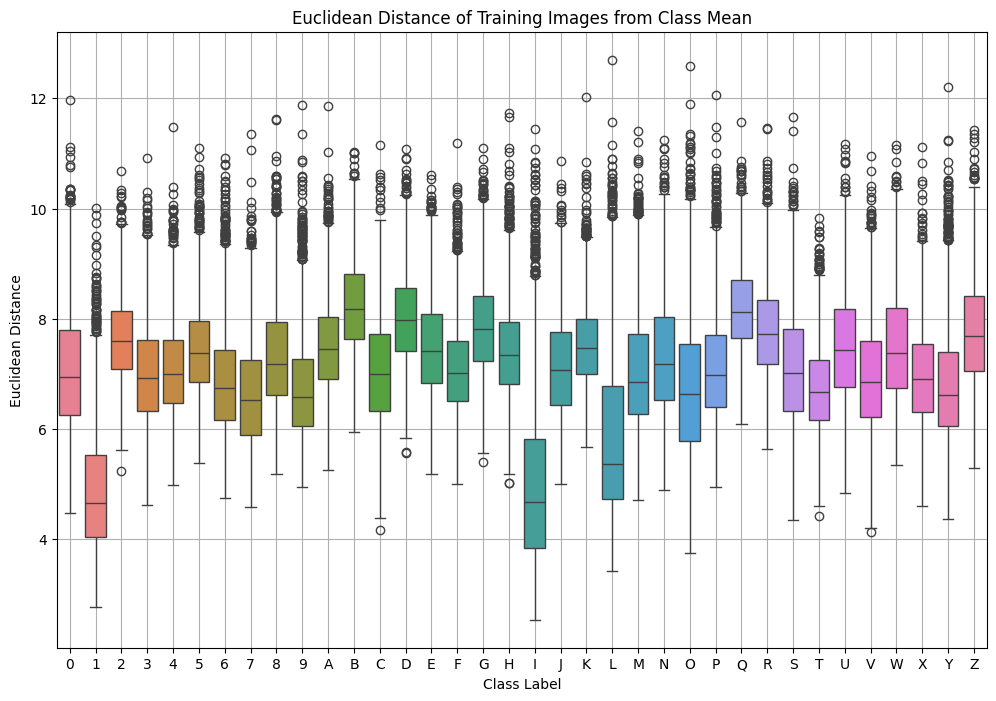

In [ ]:
def calculate_distances_from_mean(images, labels, mean_images, num_classes):
    """
    Calculate Euclidean distances between each image and its class mean.

    Parameters
    ----------
    images : numpy.ndarray
        Array of image data with shape (n_samples, height, width)
    labels : numpy.ndarray
        Array of label indices with shape (n_samples,)
    mean_images : numpy.ndarray
        Array of mean images for each class with shape (num_classes, height, width)
    num_classes : int
        Number of unique classes in the dataset

    Returns
    -------
    list
        List of numpy arrays containing distances for each class.
        Each array contains the Euclidean distances between the class images
        and their respective mean image.
    """
    distances = []
    for label in range(num_classes):
        sample_image_idx = np.where(labels == label)[0]
        class_images = images[sample_image_idx]
        class_mean = mean_images[label].reshape(1, -1)
        class_distances = pairwise_distances(class_images.reshape(class_images.shape[0], -1),
                                          class_mean,
                                          metric='euclidean')
        distances.append(class_distances.flatten())
    return distances


def plot_distances(distances, label_dict):
    """
    Create a boxplot showing the distribution of Euclidean distances for each class.

    Parameters
    ----------
    distances : list
        List of numpy arrays containing distances for each class,
        as returned by calculate_distances_from_mean()
    label_dict : dict
        Dictionary mapping class indices to their text descriptions

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=distances)
    plt.title('Euclidean Distance of Training Images from Class Mean')
    plt.xlabel('Class Label')
    plt.ylabel('Euclidean Distance')
    plt.xticks(ticks=range(len(label_dict)),
               labels=[label_dict[i] for i in range(len(label_dict))])
    plt.grid(True)
    plt.show()


distances = calculate_distances_from_mean(train_pixels, train_labels, mean_images, num_classes)
plot_distances(distances, label_dictionary)

**6.Outlier Detection and Removal Based on Euclidean Distances**

we identify and remove outliers from the dataset based on the Euclidean distances between images and their class means. The process begins by calculating the upper and lower bounds for outlier detection using the interquartile range (IQR) method.

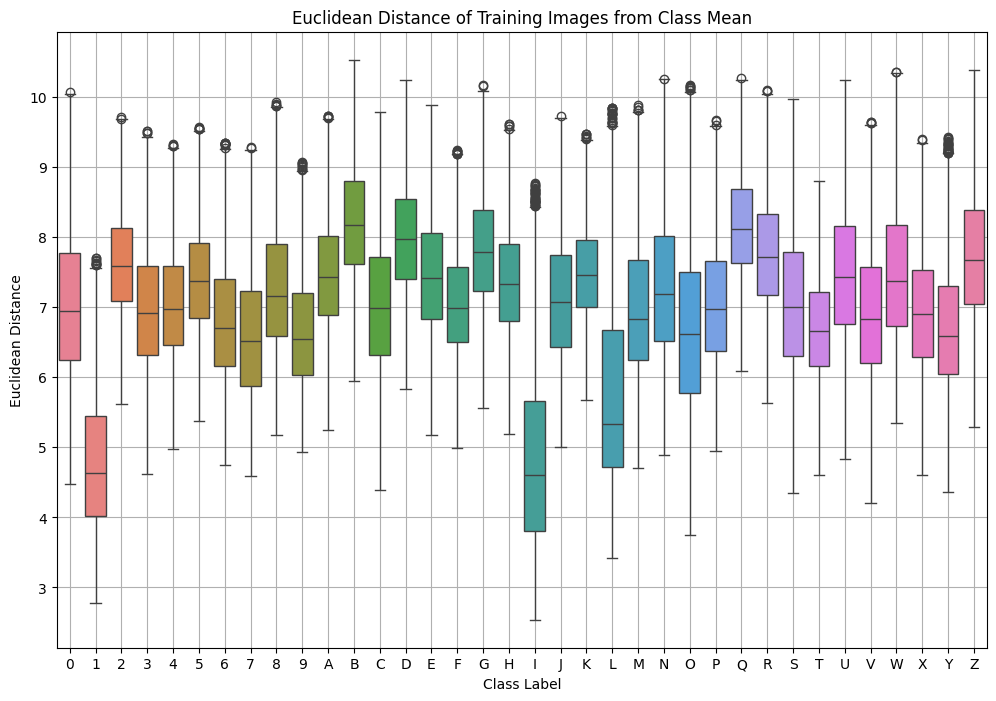

In [ ]:
def compute_bounds(distances):
    """
    Compute the upper and lower bounds for outlier detection using the boxplot method.

    Parameters
    ----------
    distances : list
        List of numpy arrays containing distances for each class,
        as returned by calculate_distances_from_mean()

    Returns
    -------
    list of tuple
        List of (lower_bound, upper_bound) tuples for each class.
        Bounds are calculated using the interquartile range (IQR) method:
        - lower_bound = Q1 - 1.5 * IQR
        - upper_bound = Q3 + 1.5 * IQR

    Notes
    -----
    The function uses the standard boxplot outlier detection method:
    1. Calculates Q1 (25th percentile) and Q3 (75th percentile)
    2. Computes IQR = Q3 - Q1
    3. Sets bounds at Q1 - 1.5*IQR and Q3 + 1.5*IQR
    """
    bounds = []
    for d in distances:
        q1 = np.percentile(d, 25)
        q3 = np.percentile(d, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        bounds.append((lower_bound, upper_bound))
    return bounds


def filter_outliers(images, labels, distances, bounds):
    """
    Filter out outlier images based on their distances from class means.

    Parameters
    ----------
    images : numpy.ndarray
        Array of image data with shape (n_samples, height, width)
    labels : numpy.ndarray
        Array of label indices with shape (n_samples,)
    distances : list
        List of numpy arrays containing distances for each class
    bounds : list of tuple
        List of (lower_bound, upper_bound) tuples for each class,
        as returned by compute_bounds()

    Returns
    -------
    tuple
        (filtered_images, filtered_labels) where:
        - filtered_images: numpy.ndarray of images with outliers removed
        - filtered_labels: numpy.ndarray of corresponding labels

    Notes
    -----
    For each class:
    1. Identifies images within the computed bounds
    2. Keeps only those images and their labels
    3. Concatenates filtered data from all classes
    """
    filtered_images = []
    filtered_labels = []
    for label in range(len(bounds)):
        sample_image_idx = np.where(labels == label)[0]
        lower_bound, upper_bound = bounds[label]
        inlier_idx = np.where(
            (distances[label] >= lower_bound) &
            (distances[label] <= upper_bound)
        )[0]
        filtered_images.append(images[sample_image_idx][inlier_idx])
        filtered_labels.append(labels[sample_image_idx][inlier_idx])

    return np.concatenate(filtered_images, axis=0), np.concatenate(filtered_labels, axis=0)



bounds = compute_bounds(distances)
train_pixels_filtered, train_labels_filtered = filter_outliers(
    train_pixels, train_labels, distances, bounds
)

# Update the training data
train_pixels = train_pixels_filtered
train_labels = train_labels_filtered

# Recalculate and visualize new distances
distances = calculate_distances_from_mean(train_pixels, train_labels, mean_images, num_classes)
plot_distances(distances, label_dictionary)

In [ ]:
# Recalculate new mean image
mean_images = calculate_mean_images(train_pixels, train_labels, num_classes)

In [ ]:
print('Filtered training data shape:', train_pixels.shape)
print('Filtered training labels shape:', train_labels.shape)

Filtered training data shape: (85300, 28, 28)
Filtered training labels shape: (85300,)


**7.Test Dataset Processing and Model Evaluation**

We load and preprocess the test dataset to evaluate the model's performance. To predict the labels for the test images, we compare each test image with the mean images of each class using Root Mean Squared Error (RMSE). For each test image, the RMSE is calculated between the image and each class's mean image. The class with the lowest RMSE is selected as the predicted label for that image

In [ ]:
# Extract the test dataset
with zipfile.ZipFile('/content/emnist-balanced-test.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
# Load the test dataset
test_dataset = pd.read_csv("/content/emnist-balanced-test.csv")
test_dataset.columns = columns

In [ ]:
# Display the first few rows and shape of the test dataset
print(test_dataset.head(10))
print('Test Data Shape:', test_dataset.shape)

# Check for missing values in test dataset and drop rows if any
print("Missing values in test dataset:", test_dataset.isna().any().any())
test_dataset = test_dataset.dropna()
print('Test Data Shape after dropping missing values:', test_dataset.shape)

# Separate class labels and pixel values
test_pixels = test_dataset.drop('label', axis=1)
test_labels = test_dataset['label'].astype('int').to_numpy()
test_pixels = np.reshape(test_pixels.values, (test_pixels.shape[0], 28, 28)) / 255

# Rotate the  test images
test_pixels=rotate_image(test_pixels)

   label  0  1  2  3  4  5  6  7  8  ...  774  775  776  777  778  779  780  \
0      9  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
1     26  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
2     33  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
3     14  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
4     11  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
5      3  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
6     12  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
7     16  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
8      7  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
9      2  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   

   781  782  783  
0    0    0    0  
1    0    0    0  
2    0    0    0  
3    0    0    0  
4    0    0    0  
5    0    0    0

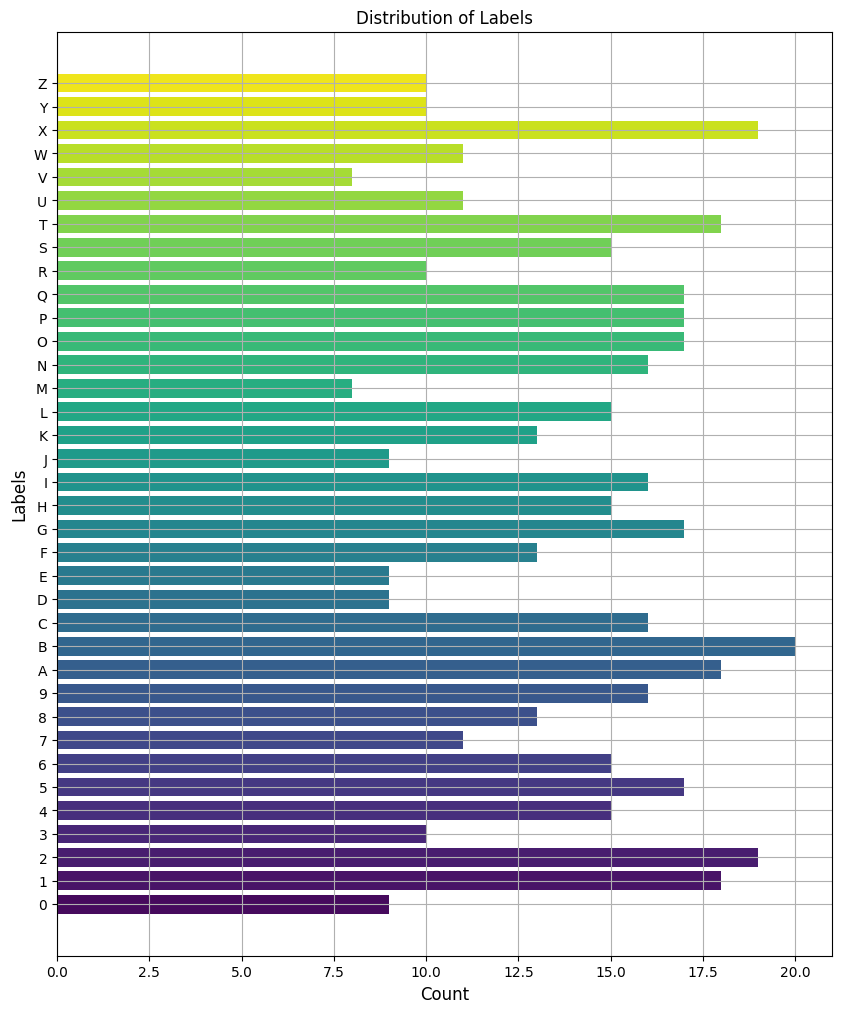

In [ ]:
# Visualize the distribution of labels
visualize_label_distribution(test_labels, label_dictionary)

To understand the performance of our non-machine learning model let's build a simple code that assigns a class according to the lowest value of RMSE among all heatmaps.

In [ ]:
def predict_labels(test_images, mean_images, num_classes):
    """
    Predict labels for test images by comparing them with mean images using RMSE.

    Parameters:
    -----------
    test_images : array-like of shape (n_samples, n_features)
        The test images to predict labels for
    mean_images : array-like of shape (n_classes, n_features)
        The mean images for each class
    num_classes : int
        Number of classes in the dataset

    Returns:
    --------
    predictions : array-like of shape (n_samples,)
        Predicted class labels
    """
    # Ensure inputs are numpy arrays
    test_images = np.asarray(test_images)
    mean_images = np.asarray(mean_images)

    # Pre-flatten arrays for efficiency
    test_flat = test_images.reshape(len(test_images), -1)
    mean_flat = mean_images.reshape(num_classes, -1)

    # Initialize array to store distances
    distances = np.zeros((len(test_images), num_classes))

    # Calculate RMSE between each test image and each mean image
    for i in range(num_classes):
        distances[:, i] = np.sqrt(np.mean((test_flat - mean_flat[i])**2, axis=1))

    # Find the class with minimum distance for each test image
    predictions = np.argmin(distances, axis=1)

    return predictions

# Predict labels for the test dataset
y_pred = predict_labels(test_pixels, mean_images, num_classes)

# Calculate and print accuracy
accuracy = accuracy_score(test_labels, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.5920


As we can see, the score is not so bad. Over 59% of accuracy for the solution without any machine learning model that still can be improved.

**8.Model Training and Evaluation with CNN**

 We train a Convolutional Neural Network (CNN) model to classify handwritten characters from the EMNIST dataset

In [ ]:
# Split the data into training and validation sets
train_x, valid_x, train_y, valid_y = train_test_split(train_pixels, train_labels, test_size=0.2, random_state=42)

In [ ]:
# Print shapes of the resulting datasets
print('Training data shape:', train_x.shape)
print('Training labels shape:', train_y.shape)
print('Validation data shape:', valid_x.shape)
print('Validation labels shape:', valid_y.shape)

Training data shape: (68240, 28, 28)
Training labels shape: (68240,)
Validation data shape: (17060, 28, 28)
Validation labels shape: (17060,)


In [ ]:
# Define the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])
# Print model summary
model.summary()

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(train_x, train_y, validation_data=(valid_x, valid_y), epochs=10)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 36)                  │           4,644 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 116,740 (456.02 KB)

 Trainable params: 116,740 (456.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.5573 - loss: 1.4994 - val_accuracy: 0.8624 - val_loss: 0.3889
Epoch 2/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.8166 - loss: 0.5473 - val_accuracy: 0.8857 - val_loss: 0.3181
Epoch 3/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 85s 25ms/step - accuracy: 0.8421 - loss: 0.4512 - val_accuracy: 0.8921 - val_loss: 0.2882
Epoch 4/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.8601 - loss: 0.3942 - val_accuracy: 0.8934 - val_loss: 0.2827
Epoch 5/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 83s 24ms/step - accuracy: 0.8702 - loss: 0.3587 - val_accuracy: 0.8991 - val_loss: 0.2675
Epoch 6/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - accuracy: 0.8778 - loss: 0.3358 - val_accuracy: 0.9004 - val_loss: 0.2628
Epoch 7/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 81s 25ms/step - accuracy: 0.8843 - loss: 0.3163 - val_accuracy: 0.9056 - val_loss: 0.2569
Epoch 8/10
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - accuracy: 0.8898 -

In [ ]:
def plot_accuracy_loss(history):
    """Plot training and validation accuracy and loss over epochs."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))  # Get number of epochs

    # Plot training and validation accuracy per epoch
    plt.plot(epochs, acc, 'r', label="Training Accuracy")
    plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='best')
    plt.figure()

    # Plot training and validation loss per epoch
    plt.plot(epochs, loss, 'r', label="Training Loss")
    plt.plot(epochs, val_loss, 'b', label="Validation Loss")
    plt.title('Training and Validation Loss')
    plt.legend(loc='best')
    plt.show()

In [ ]:
def print_model_metrics(model, data, labels):
    """Evaluate and print model metrics (loss and accuracy)."""
    loss, accuracy = model.evaluate(data, labels, verbose=0)
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("-" * 20)

In [ ]:
# Function to compute and plot confusion matrix
def plot_confusion_matrix(true_labels, predicted_labels, label_dict, num_classes):
    # Compute confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(20, 12))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")

    # Set ticks and labels
    ticks = np.arange(num_classes) + 0.5
    labels = [label_dict[i] for i in range(num_classes)]
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels, rotation=0)

    plt.show()



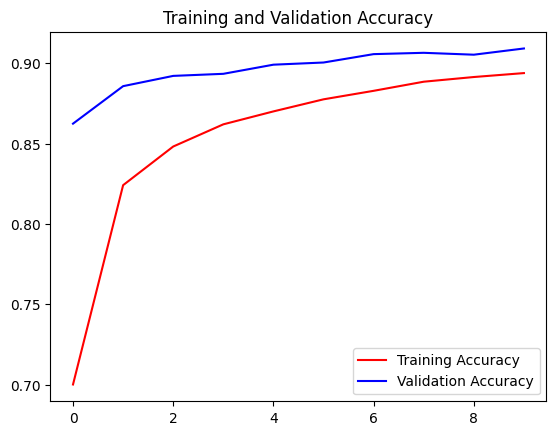

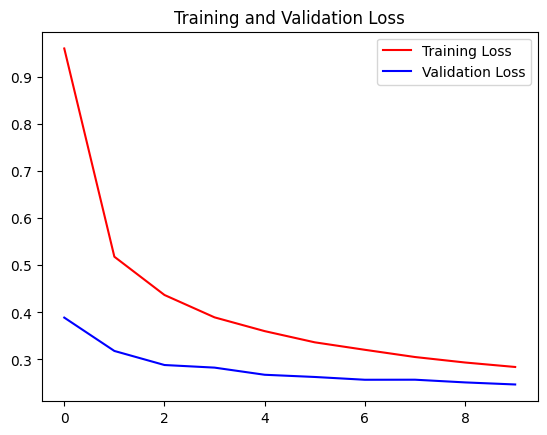

Validation set metrics:
Loss: 0.2469
Accuracy: 0.9091
--------------------
Test set metrics:
Loss: 0.3065
Accuracy: 0.9140
--------------------


In [ ]:
# Plot accuracy and loss curves
plot_accuracy_loss(history)

# Print model metrics on validation and test datasets
print("Validation set metrics:")
print_model_metrics(model, valid_x, valid_y)

print("Test set metrics:")
print_model_metrics(model, test_pixels, test_labels)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Confusion Matrix (Test Data):


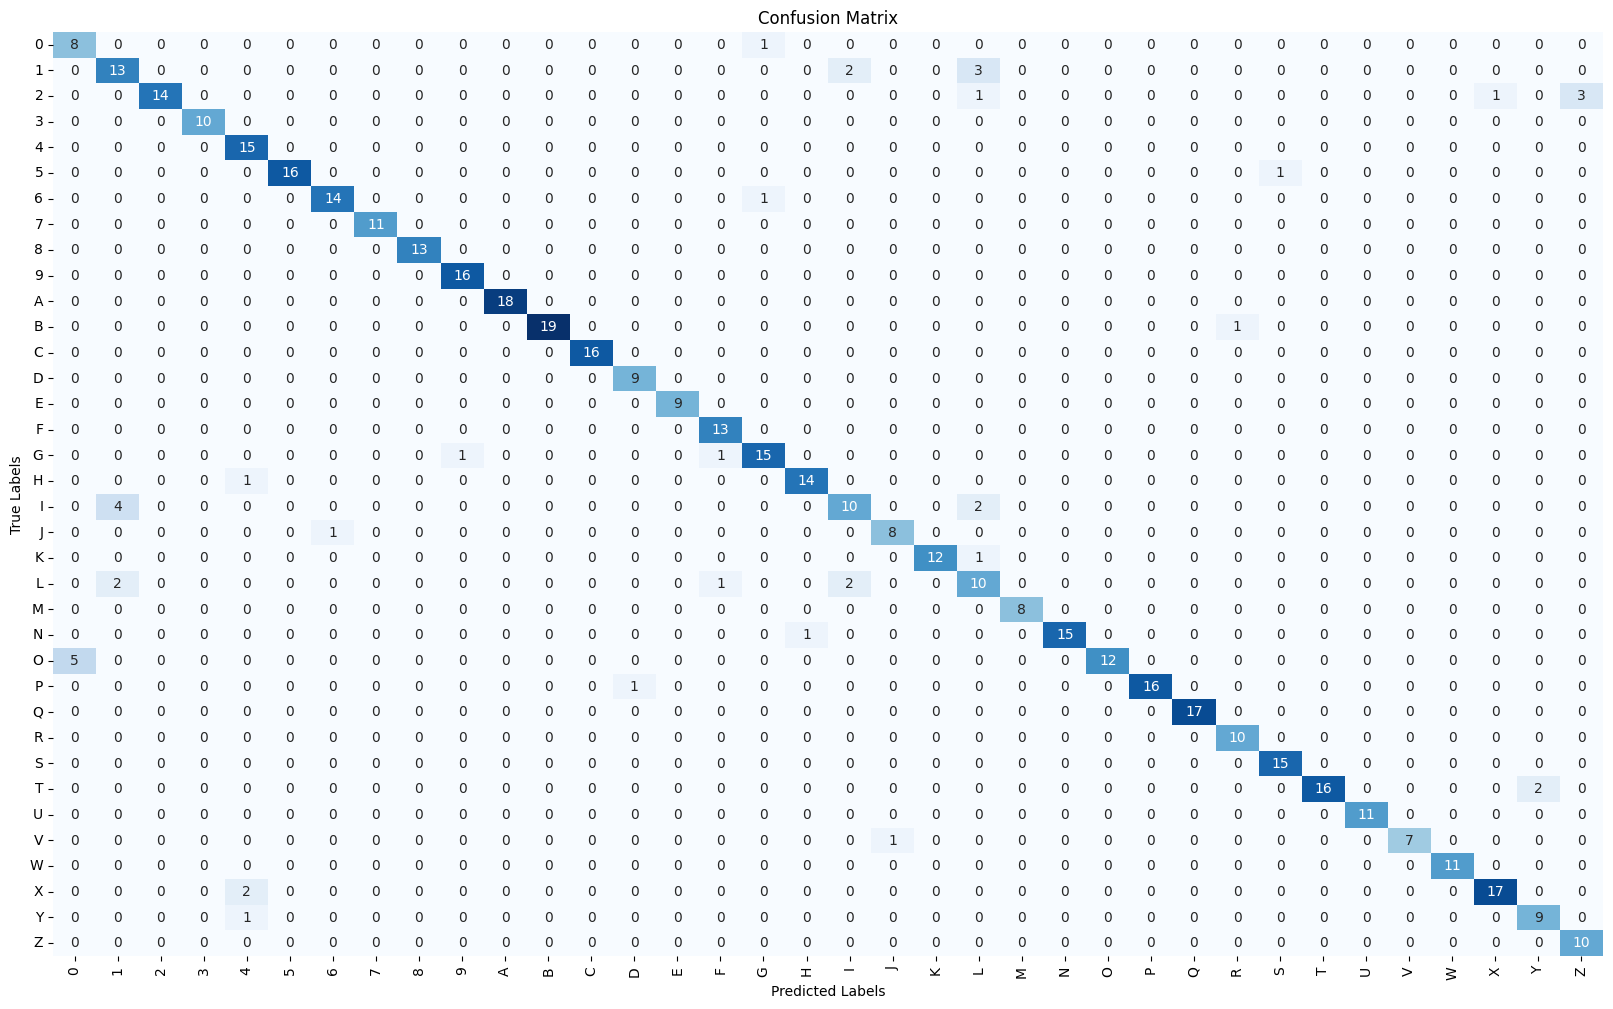

In [ ]:
# Make predictions on the test data
test_predictions = model.predict(test_pixels)
test_pred_labels = np.argmax(test_predictions, axis=1)

# Plot confusion matrix for test data
print("Confusion Matrix (Test Data):")
plot_confusion_matrix(test_labels, test_pred_labels, label_dictionary, num_classes)